In [1]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
# Check if __file__ is defined, if not, define it as the current working directory
if '__file__' not in globals():
    __file__ = os.path.abspath(".")

In [3]:
from pynq.overlay import Overlay
os.environ['BOARD'] = 'RFSoC4x2'
import xrfclk
import pynq
import pynq.lib
import sys

# Adjust the sys.path to include the directory of the current file
sys.path.insert(0, os.path.abspath(os.path.dirname(__file__)))

In [4]:
overlay = Overlay("adc_dma.bit")
overlay.download()

In [5]:
print(overlay.ip_dict.keys())

dict_keys(['axi_dma_0', 'axi_intc_0', 'usp_rf_data_converter_0', 'zynq_ultra_ps_e_0'])


In [7]:
from pynq.lib.dma import DMA

dma_recv = DMA(overlay.ip_dict['axi_dma_0'])


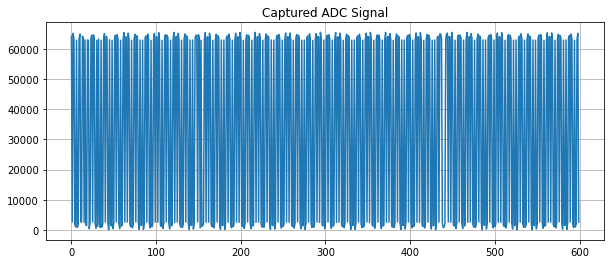

In [52]:
from pynq import allocate
import numpy as np
import matplotlib.pyplot as plt

# 1. Allocate a DMA-safe buffer for capture
# Using 'u2' to match your DAC code's unsigned 16-bit format
# Ensure data_size is a multiple of 8 for alignment
capture_size = 16384 
adc_buffer = allocate(shape=(capture_size,), dtype='u2')

# 2. Capture Function
def capture_wave():
    # Start the DMA receive channel transfer
    dma_recv.recvchannel.transfer(adc_buffer)
    dma_recv.recvchannel.wait()
    
    # Copy to a numpy array for processing
    return np.array(adc_buffer)

# 3. Visualization logic
captured_data = capture_wave()
plt.figure(figsize=(10,4))
plt.plot(captured_data[:600]) # Plot first 500 samples to see the wave
plt.title("Captured ADC Signal")
plt.grid(True)
plt.show()

Detected Input Frequency: 100.70 MHz


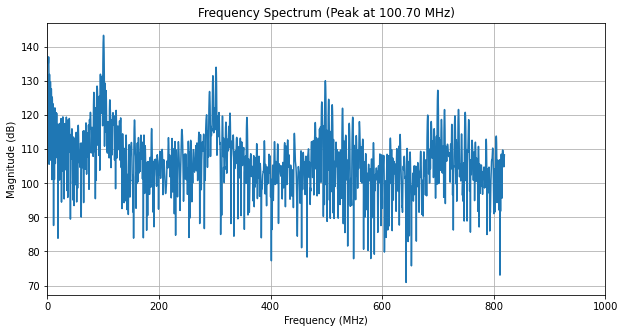

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Final Hardware Parameters
# 4915.2 / 3 decimation = 1638.4 MSPS
ADC_SAMPLE_RATE_MSPS = 1638.4

# 2. Process Capture
captured_data = capture_wave()
# Remove DC offset to keep 0Hz clean
signal = captured_data.astype(np.float32) - np.mean(captured_data)

# 3. FFT
n = len(signal)
fft = np.fft.fft(signal)
freqs = np.fft.fftfreq(n, 1/(ADC_SAMPLE_RATE_MSPS * 1e6))

# 4. Automatic Peak Detection (Updated)
# We skip the first 10 bins to ignore the DC/0Hz spike
ignore_bins = 20 
pos_freqs = freqs[ignore_bins:n//2] / 1e6
pos_mag = np.abs(fft[ignore_bins:n//2])

# Now argmax will find your real 50MHz signal
peak_freq = pos_freqs[np.argmax(pos_mag)]

print(f"Detected Input Frequency: {peak_freq:.2f} MHz")
# 5. Plotting
plt.figure(figsize=(10, 5))
plt.plot(pos_freqs, 20*np.log10(pos_mag + 1e-9))
plt.title(f'Frequency Spectrum (Peak at {peak_freq:.2f} MHz)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Magnitude (dB)')
plt.xlim([0, 1000]) # Focused view for your 50MHz signal
plt.grid(True)
plt.show()

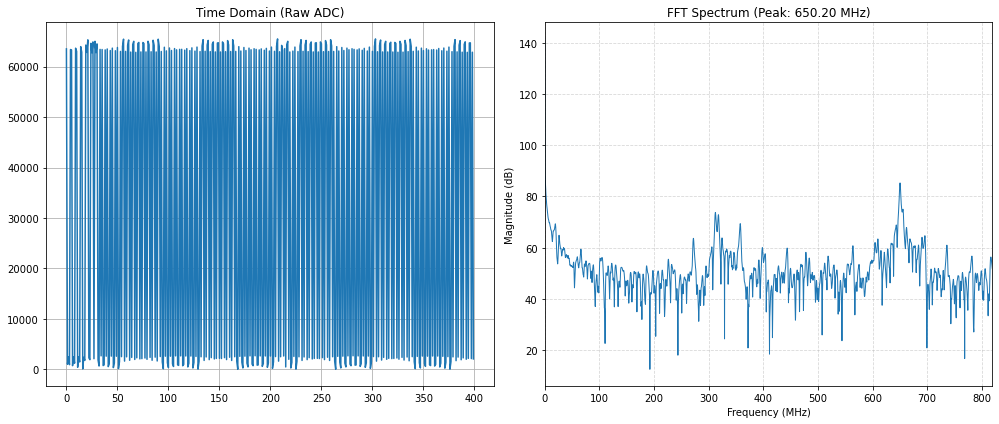

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# --- HARDWARE CONSTANTS ---
# 4915.2 GSPS / 3 (Decimation) = 1638.4 MSPS
ADC_SAMPLE_RATE_MSPS = 1638.4 

def get_clean_fft(data, num_averages=1):
    # 1. Remove DC Offset and apply Blackman-Harris window
    # This removes the "square wave" harmonics and spectral leakage
    centered_data = data.astype(np.float32) - np.mean(data)
    win = windows.blackmanharris(len(centered_data))
    windowed_signal = centered_data * win
    
    # 2. Perform FFT
    n = len(windowed_signal)
    fft_res = np.fft.fft(windowed_signal)
    freqs = np.fft.fftfreq(n, 1/(ADC_SAMPLE_RATE_MSPS * 1e6))
    
    # 3. Clean Peak Detection (Skip first 20 bins to ignore DC)
    ignore_bins = 20
    pos_freqs = freqs[ignore_bins:n//2] / 1e6
    pos_mag = np.abs(fft_res[ignore_bins:n//2])
    peak_freq = pos_freqs[np.argmax(pos_mag)]
    
    return freqs[:n//2]/1e6, 20*np.log10(np.abs(fft_res[:n//2]) + 1e-9), peak_freq

# Execute Capture and Analysis
raw_adc_data = capture_wave()
f_axis, mag_axis, detected_f = get_clean_fft(raw_adc_data)

# --- VISUALIZATION ---
plt.figure(figsize=(14, 6))

# Subplot 1: Time Domain (Center around 0)
plt.subplot(1, 2, 1)
plt.plot(raw_adc_data[:400]) # Zoomed view to see waves
plt.title('Time Domain (Raw ADC)')
plt.grid(True)

# Subplot 2: Cleaned Frequency Domain
plt.subplot(1, 2, 2)
plt.plot(f_axis, mag_axis, color='tab:blue', linewidth=1)
plt.title(f'FFT Spectrum (Peak: {detected_f:.2f} MHz)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Magnitude (dB)')
plt.xlim([0, 819.2]) # Set to the Nyquist limit
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()